# 2026-01-19 directed energy weapon feasibility EM calculation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Lower-frequency focusing challenge
Even at 1 GHz, you lose focus

In [2]:
c = 3*10**8 # [m/s]
def freq_to_lambda(freq):
    return c / freq # [m]


At 1 GHz, the wavelength is:

In [3]:
l = freq_to_lambda(10**9) # [m]
l

0.3

Angular resolution is approximately:
$$ \theta \approx 1.22 \frac{\lambda}{D} $$

where
- $\theta$ = beam half-angle (radians)
- $\lambda$ = wavelength
- $D$ = antenna diameter (aperture)

In [4]:
D = 0.5
theta = 1.22 * l / D
theta

0.732

Using farfield divergence,
$$ \omega=R*\theta$$
And at $R$ = 100m and $\theta=0.73$,

In [5]:
100 * theta # [m]

73.2

## Tissue absorption challenge at high frequency

A simple first-order attenuation model in tissue (exponential):

$$ P(z) = P_0 \exp(-2 \alpha z)

where
- $z$ = distance
- $\alpha$ = attenuation constant

Computing using the constants from https://itis.swiss/virtual-population/tissue-properties/database/dielectric-properties/

Model from "The dielectric properties of biological tissues: III. Parametric models for the dielectric spectrum of tissues" Gabriel, Lau & Gabriel 1996

In [6]:
eps0 = 8.854187817e-12 # vacuum permittivity [F/m]
mu0 = 4*np.pi*1e-7 # vacuum permeability [H/m]

def attenuation_alpha(freq_hz, eps_r, sigma_s_m):
    """
    Compute EM attenuation constant alpha (Np/m) for a lossy dielectric (non-magnetic tissue).

    freq_hz: frequency in Hz
    eps_r: relative permittivity (dimensionless, real part)
    sigma_s_m: electrical conductivity in S/m

    alpha: ttenuation constant in Np/m
    """
    omega = 2 * np.pi * freq_hz

    # imaginary permittivity from conductivity
    eps_imag = sigma_s_m / (omega * eps0)

    # closed-form attenuation expression
    alpha = omega * np.sqrt(mu0 * eps0 / 2) * np.sqrt(
        np.sqrt(eps_r**2 + eps_imag**2) - eps_r
    )

    return alpha


In [7]:
# permittivity, electric conductance (S/m)
dielectric_data = {
    0.1: (80.1, 0.559),
    1: (52.3, 0.985),
    10: (38.1, 10.3),
    100: (7.76,53.2)
}

In [8]:
f = 95e9          # 10 GHz
eps_r = 8.01      # relative permittivity
sigma = 52.6       # S/m
alpha = attenuation_alpha(f, eps_r, sigma)

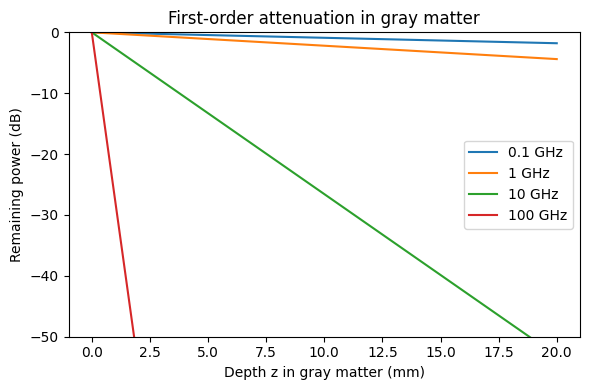

In [9]:
list_freq = [0.1, 1, 10, 100]
z = np.linspace(0,0.02,num=100)

plt.figure(figsize=(6,4))
for f_ghz in list_freq:
    f = f_ghz * 1e9
    eps_r, sigma = dielectric_data[f_ghz]
    alpha = attenuation_alpha(f, eps_r, sigma)
    plt.plot(z*1000,10*np.log10(np.exp(-2 * alpha * z)), label=f"{f_ghz} GHz")

plt.title("First-order attenuation in gray matter")
plt.ylabel("Remaining power (dB)")
plt.xlabel("Depth z in gray matter (mm)")
plt.legend()
plt.ylim(-50,0)
plt.tight_layout()